# Regime-Conditional Portfolio Optimisation: CVaR & DRO

This notebook builds and evaluates regime-conditional portfolio strategies on the **test set (Jan 2021 – present)**.

**Strategies:**
- CVaR (Regime-Conditional) — minimises CVaR using scenarios weighted toward the current GMM regime
- DRO (Regime-Conditional) — Wasserstein distributionally robust CVaR with regime conditioning
- CVaR (Unconditional) — same CVaR but ignores regime (full-history scenarios)

**Benchmarks:**
- Equal Weight (1/N)
- 60/40 (MSCI ACWI / Global Govt Bonds)
- Risk Parity (inverse volatility)
- MVO (max Sharpe, classical Markowitz)

**Prerequisites:** Run `regime_analysis.ipynb` first to generate the regime model outputs.

In [16]:
import sys, os, warnings, time
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick

# ── Matplotlib backend ────────────────────────────────────────────────────────
# If plots are not showing: Kernel → Restart & Run All
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
print('Environment ready. matplotlib backend:', matplotlib.get_backend())

Environment ready. matplotlib backend: module://matplotlib_inline.backend_inline


## 1. Load Data
Load asset returns, regime labels, and probabilities produced by `regime_analysis.ipynb`.

In [17]:
# Reload FIRST — before any other cell imports portfolio_optimiser
import importlib, sys
# Clear any cached version from __pycache__
if 'portfolio_optimiser' in sys.modules:
    del sys.modules['portfolio_optimiser']
import portfolio_optimiser
importlib.reload(portfolio_optimiser)

from data_cleaner import build_clean_dataset
from portfolio_optimiser import ASSET_TICKERS, ASSET_LABELS

START_DATE = '2002-01-02'
TEST_START = '2021-01-01'

# ── Asset returns ─────────────────────────────────────────────────────────────
dataset = build_clean_dataset(start=START_DATE)
returns_full = dataset['returns']

# Select and validate asset universe
available_assets = [t for t in ASSET_TICKERS if t in returns_full.columns]
missing_assets   = [t for t in ASSET_TICKERS if t not in returns_full.columns]

print(f'Asset universe: {len(available_assets)}/{len(ASSET_TICKERS)} available')
if missing_assets:
    print(f'  Missing (will be excluded): {missing_assets}')
for t in available_assets:
    print(f'  {t:12s}  {ASSET_LABELS[t]}')

returns = returns_full[available_assets].dropna(how='all')

# ── Train / test split ────────────────────────────────────────────────────────
returns_train = returns[returns.index <  TEST_START]
returns_test  = returns[returns.index >= TEST_START]

print(f'\nTrain: {returns_train.index[0].date()} → {returns_train.index[-1].date()}  ({len(returns_train)} days)')
print(f'Test:  {returns_test.index[0].date()}  → {returns_test.index[-1].date()}  ({len(returns_test)} days)')

[portfolio_optimiser] loaded: portfolio_optimiser v5 — LP long-only CVaR/DRO
[portfolio_optimiser] loaded: portfolio_optimiser v5 — LP long-only CVaR/DRO
Asset universe: 10/10 available
  MXCXDMHR      Global Equity
  RU30INTR      US Equity
  MXEF          EM Equity
  BCOMTR        Commodities
  LGY7TRUH      Rates 7-10yr
  LUACTRUU      US IG Credit
  LF98TRUU      US HY Credit
  BCIT5T        US TIPS
  EMUSTRUU      EM Bonds
  PUT           Short Vol

Train: 2002-01-03 → 2020-12-31  (4956 days)
Test:  2021-01-01  → 2026-06-09  (1418 days)


In [18]:
# ── Regime labels and probabilities ──────────────────────────────────────────
def _load_csv_series(path, col, date_col='Date'):
    df = pd.read_csv(path, index_col=date_col, parse_dates=True)
    return df[col]

def _load_csv_df(path, date_col='Date'):
    return pd.read_csv(path, index_col=date_col, parse_dates=True)

import os
# Try both filenames (all vs non-all)
for fname in ['outputs/regime_hard_labels_all.csv', 'outputs/regime_hard_labels.csv']:
    if os.path.exists(fname):
        hard_labels_all = _load_csv_series(fname, 'regime_int')
        print(f'Loaded regime labels from: {fname}')
        break
else:
    raise FileNotFoundError("Run regime_analysis.ipynb first to generate regime labels.")

for fname in ['outputs/regime_probabilities_all.csv', 'outputs/regime_probabilities.csv']:
    if os.path.exists(fname):
        regime_probs_all = _load_csv_df(fname)
        print(f'Loaded regime probs from: {fname}')
        break
else:
    raise FileNotFoundError("Run regime_analysis.ipynb first to generate regime probabilities.")

hard_labels_train = hard_labels_all[hard_labels_all.index <  TEST_START]
hard_labels_test  = hard_labels_all[hard_labels_all.index >= TEST_START]
regime_probs_test = regime_probs_all[regime_probs_all.index >= TEST_START]

# Regime name mapping
named_labels = _load_csv_df('outputs/regime_named_labels.csv')
regime_names = (
    hard_labels_all.to_frame('regime_int')
    .join(named_labels.rename(columns={'regime': 'regime_name'}))
    .dropna().drop_duplicates()
    .set_index('regime_int')['regime_name'].to_dict()
)
regime_names = {int(k): v for k, v in regime_names.items()}

print(f'Regime labels loaded: {len(hard_labels_all)} obs')
print(f'Regime names: {regime_names}')
print(f'Test-set regime distribution:')
for k, label in regime_names.items():
    cnt = (hard_labels_test == k).sum()
    pct = 100 * cnt / len(hard_labels_test)
    print(f'  {label:20s}: {cnt:4d} days ({pct:.1f}%)')

Loaded regime labels from: outputs/regime_hard_labels_all.csv
Loaded regime probs from: outputs/regime_probabilities_all.csv
Regime labels loaded: 5974 obs
Regime names: {1: 'WOI', 2: 'Steady_State', 3: 'Inflation', 0: 'Crisis'}
Test-set regime distribution:
  WOI                 :  714 days (51.2%)
  Steady_State        :  460 days (33.0%)
  Inflation           :   55 days (3.9%)
  Crisis              :  166 days (11.9%)


## 2. Run Backtest

Monthly rebalance, walk-forward. The GMM is **not re-trained** — we use the training-period model throughout, which is the correct out-of-sample setup.

In [19]:
from portfolio_optimiser import run_backtest

t0 = time.time()

result = run_backtest(
    returns_test       = returns_test,
    returns_train      = returns_train,
    hard_labels_train  = hard_labels_train,
    hard_labels_test   = hard_labels_test,
    regime_probs_test  = regime_probs_test,
    regime_names       = regime_names,
    alpha              = 0.95,
    dro_kappa          = 1.0,
    regime_boost       = 5.0,
    n_scenarios        = 1000,
    rebalance_freq     = 'D',
    lookback_days      = 756,
    expanding_window   = False,
    verbose            = True,
)

print(f'\nBacktest completed in {time.time()-t0:.1f}s')
print(f'Test period: {result.portfolio_returns.index[0].date()} \u2192 {result.portfolio_returns.index[-1].date()}')
result.portfolio_returns.to_csv('outputs/portfolio_returns.csv')
print('Saved: outputs/portfolio_returns.csv')

  2021-01-01  [Inflation      ]  top: Rates 7-10yr=84%
  2021-02-01  [WOI            ]  top: Rates 7-10yr=67%
  2021-03-01  [Crisis         ]  top: Rates 7-10yr=92%
  2021-04-01  [WOI            ]  top: Rates 7-10yr=83%
  2021-06-01  [WOI            ]  top: Rates 7-10yr=76%
  2021-07-01  [Steady_State   ]  top: Rates 7-10yr=62%
  2021-09-01  [Inflation      ]  top: Rates 7-10yr=77%
  2021-10-01  [WOI            ]  top: Rates 7-10yr=68%
  2021-11-01  [WOI            ]  top: Rates 7-10yr=83%
  2021-12-01  [Crisis         ]  top: Rates 7-10yr=95%
  2022-02-01  [WOI            ]  top: Rates 7-10yr=79%
  2022-03-01  [Crisis         ]  top: Rates 7-10yr=99%
  2022-04-01  [WOI            ]  top: Rates 7-10yr=73%
  2022-06-01  [WOI            ]  top: Rates 7-10yr=70%
  2022-07-01  [Crisis         ]  top: Rates 7-10yr=97%
  2022-08-01  [WOI            ]  top: Rates 7-10yr=77%
  2022-09-01  [Crisis         ]  top: Rates 7-10yr=97%
  2022-11-01  [WOI            ]  top: Rates 7-10yr=80%
  2022-12-

In [20]:
# ── OPTIONAL: Expanding-window (rolling GMM refit) ───────────────────────────
# Set run_expanding = True to refit the GMM every month on all available data.
# This means the regime model itself evolves over the test period, so the
# expected return / volatility estimates used for optimisation update monthly.
# Note: this adds ~2-5 min of compute. See discussion cell below.

run_expanding = False   # ← change to True to enable

if run_expanding:
    from factor_construction import build_factor_matrix
    factor_matrix_full = build_factor_matrix(start=START_DATE, include_style=True,
                                              halflife_days=60, min_periods=126)
    result_expanding = run_backtest(
        returns_test       = returns_test,
        returns_train      = returns_train,
        hard_labels_train  = hard_labels_train,
        hard_labels_test   = hard_labels_test,
        regime_probs_test  = regime_probs_test,
        regime_names       = regime_names,
        alpha              = 0.95,
        lam                = 0.10,
        cvar_max_weight    = 0.40,
        cvar_min_weight    = 0.02,
        rebalance_freq     = 'D',
        lookback_days      = 756,
        n_scenarios        = 500,
        expanding_window   = True,
        factor_matrix_full = factor_matrix_full,
        n_components       = 4,
        verbose            = True,
    )
    result_expanding.portfolio_returns.to_csv('outputs/portfolio_returns_expanding.csv')
    result_expanding.metrics.to_csv('outputs/portfolio_metrics_expanding.csv')
    print('Expanding-window backtest complete.')
    print(result_expanding.metrics[['Ann. Return (%)', 'Sharpe Ratio', 'Sortino Ratio']].to_string())
else:
    print('Expanding window not run. Set run_expanding=True above to enable.')

Expanding window not run. Set run_expanding=True above to enable.


## 3. Performance Metrics

In [21]:
print('=' * 90)
print('PERFORMANCE METRICS — Test Period (Jan 2021 – present)')
print('=' * 90)
print(result.metrics.T.to_string())

result.metrics.to_csv('outputs/portfolio_metrics.csv')
print('\nSaved: outputs/portfolio_metrics.csv')

PERFORMANCE METRICS — Test Period (Jan 2021 – present)
                       CVaR (Regime)  DRO (Regime)  CVaR (Unconditional)  Equal Weight  Risk Parity      MVO
Ann. Return (%)               1.9600        1.9600                1.0700        6.1400       3.6500   1.2900
Ann. Vol (%)                  3.6700        3.6700                3.6700        6.3300       4.7100   8.9300
Sharpe Ratio                  0.5340        0.5340                0.2920        0.9690       0.7760   0.1450
Sortino Ratio                 0.5400        0.5400                0.2990        0.8930       0.7130   0.1190
CVaR 95% (%)                  8.0900        8.0900                7.8900       15.1200      11.3500  25.8500
Max Drawdown (%)            -12.9700      -12.9700              -13.8300      -17.1800     -17.1000 -24.4200
Calmar Ratio                  0.1510        0.1510                0.0770        0.3570       0.2140   0.0530
Sharpe (Crisis)               0.3510        0.3510                0.4940 

## 4. Figures

In [22]:
# ── Colour scheme ─────────────────────────────────────────────────────────────
COLOURS = {
    'CVaR (Regime)':         '#1a5fa8',   # deep blue  — primary strategy
    'DRO (Regime)':          '#1a9e6b',   # teal green — primary strategy
    'CVaR (Unconditional)':  '#6e9fc9',   # light blue — ablation
    'Equal Weight':          '#aaaaaa',   # grey
    'Risk Parity':           '#c84040',   # red
    'MVO':                   '#7c4dcc',   # purple
}

REGIME_COLOURS = {
    'Crisis':       '#c0392b',
    'Steady_State': '#27ae60',
    'WOI':          '#e67e22',
    'Inflation':    '#8e44ad',
}

def _regime_bg(ax, regime_labels, dates):
    """Shade background by regime."""
    common = dates.intersection(regime_labels.index)
    rl = regime_labels.loc[common]
    for i in range(len(common) - 1):
        reg  = rl.iloc[i]
        col  = REGIME_COLOURS.get(reg, '#dddddd')
        ax.axvspan(common[i], common[i+1], alpha=0.07, color=col, linewidth=0)

print('Colour scheme defined.')

Colour scheme defined.


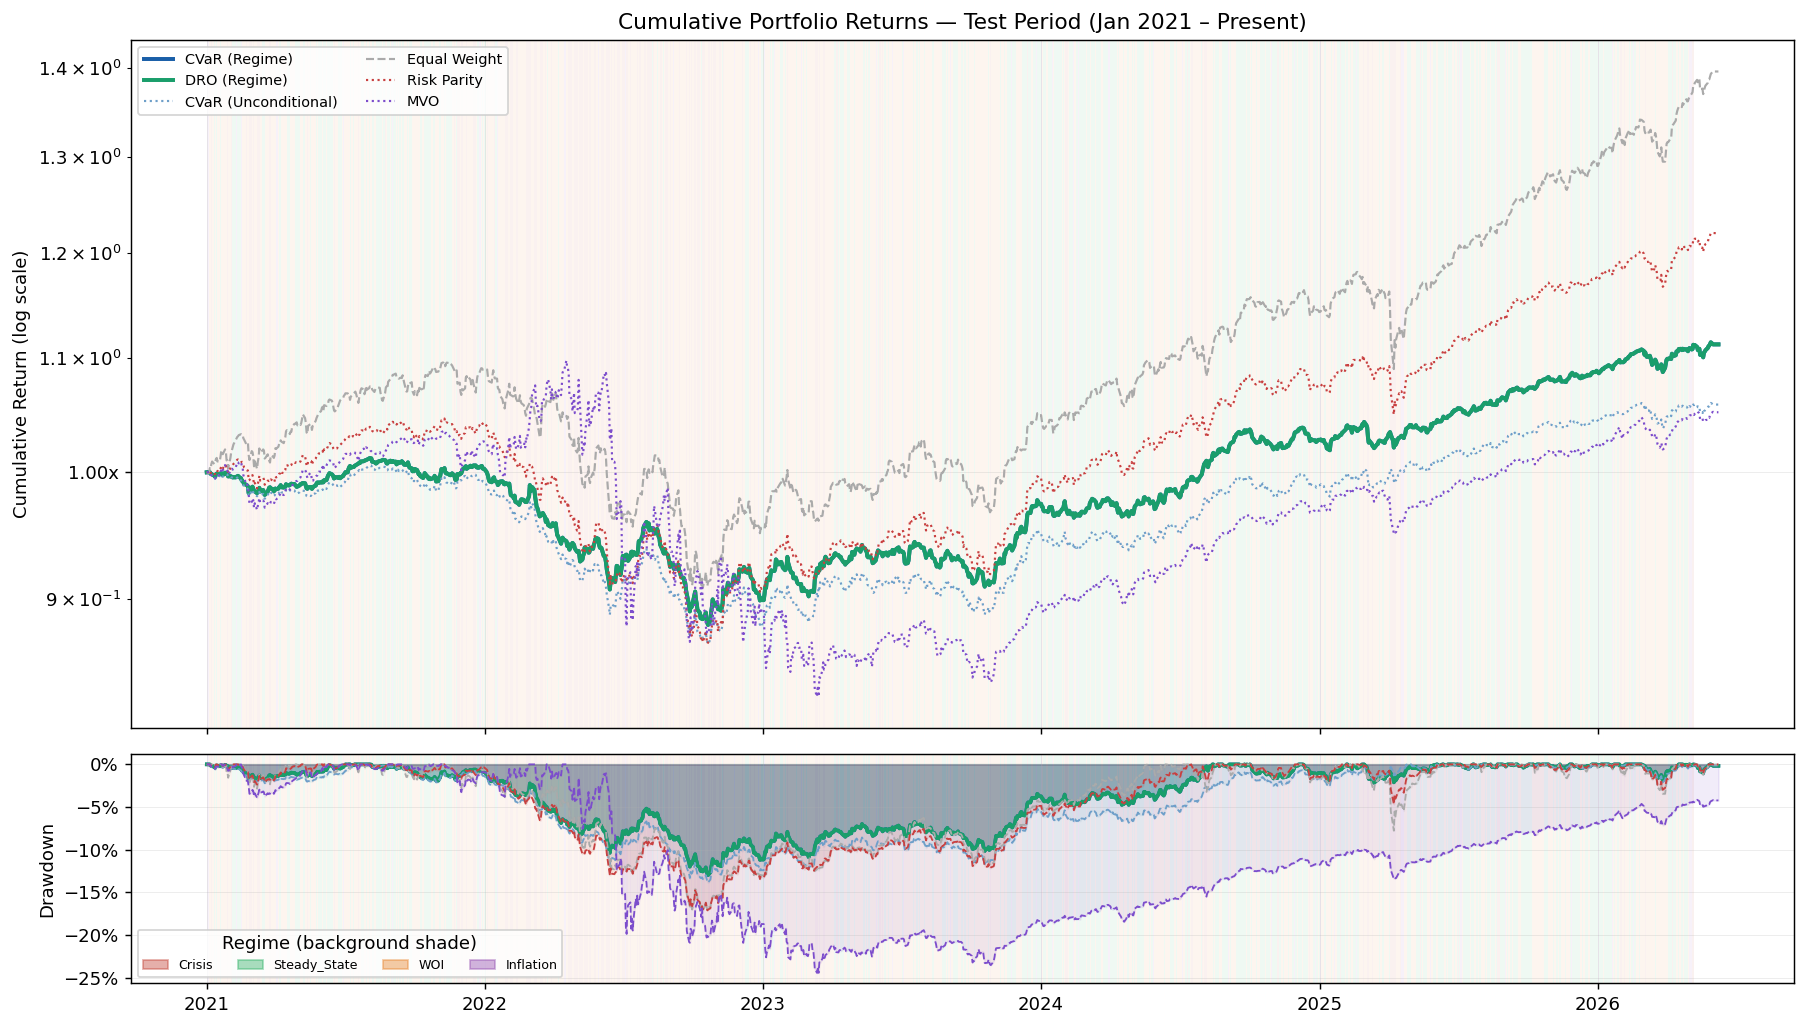

Saved: outputs/figures/08_cumulative_returns.png


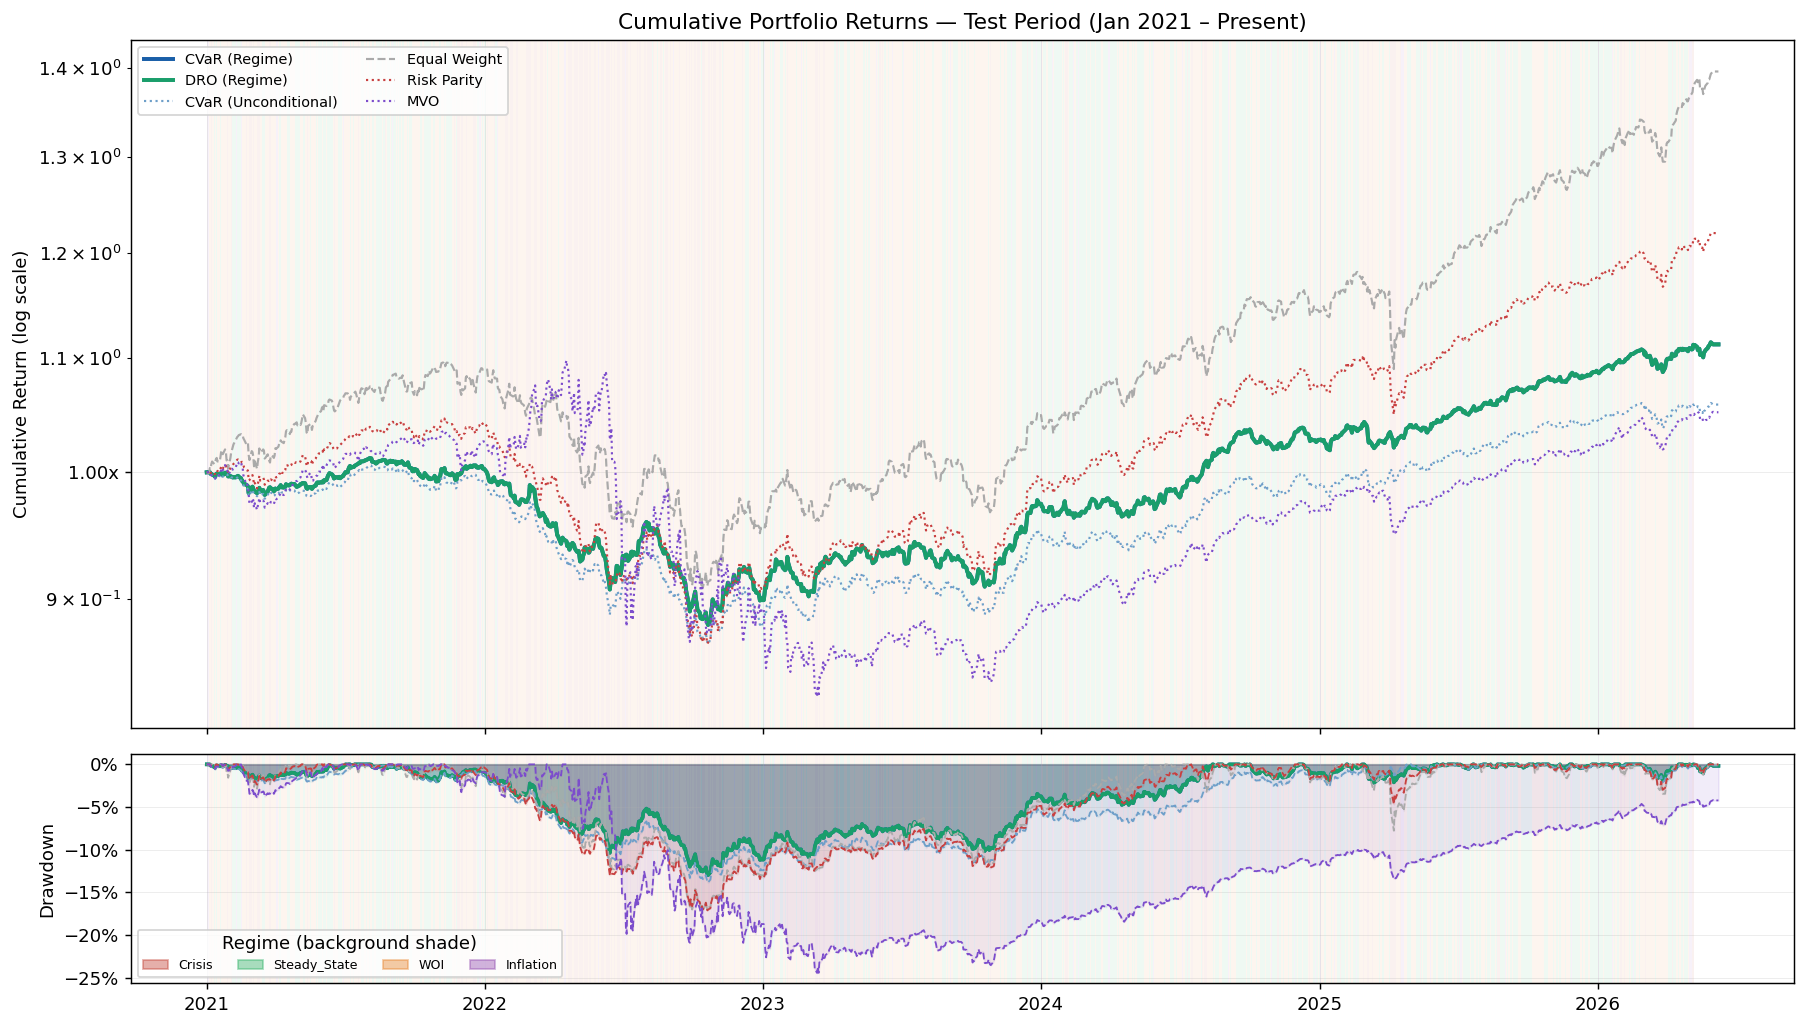

In [23]:
# ── Figure 1: Cumulative Return ───────────────────────────────────────────────
pr = result.portfolio_returns
cum = (1 + pr).cumprod()

fig, (ax_main, ax_dd) = plt.subplots(2, 1, figsize=(14, 8),
                                      gridspec_kw={'height_ratios': [3, 1]},
                                      sharex=True)

# Cumulative return
for strat, color in COLOURS.items():
    if strat in cum.columns:
        lw   = 2.2 if 'Regime' in strat else 1.2
        ls   = '-'  if 'Regime' in strat else ('--' if strat in ['60/40','Equal Weight'] else ':')
        ax_main.plot(cum.index, cum[strat], label=strat, color=color, lw=lw, ls=ls)

_regime_bg(ax_main, result.regime_labels, cum.index)
ax_main.set_ylabel('Cumulative Return (log scale)')
ax_main.set_yscale('log')
ax_main.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x:.2f}x'))
ax_main.legend(loc='upper left', fontsize=8, ncol=2)
ax_main.set_title('Cumulative Portfolio Returns — Test Period (Jan 2021 – Present)', fontsize=12)
ax_main.grid(alpha=0.25, lw=0.5)

# Drawdown
for strat, color in COLOURS.items():
    if strat not in cum.columns: continue
    peak = cum[strat].cummax()
    dd   = (cum[strat] - peak) / peak
    lw   = 2.0 if 'Regime' in strat else 1.0
    ax_dd.fill_between(dd.index, dd, 0, alpha=0.25 if 'Regime' in strat else 0.10, color=color)
    ax_dd.plot(dd.index, dd, color=color, lw=lw, ls=('-' if 'Regime' in strat else '--'))

ax_dd.set_ylabel('Drawdown')
ax_dd.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax_dd.grid(alpha=0.25, lw=0.5)
_regime_bg(ax_dd, result.regime_labels, cum.index)

# Regime legend
patches = [mpatches.Patch(color=c, alpha=0.4, label=r)
           for r, c in REGIME_COLOURS.items()]
ax_dd.legend(handles=patches, loc='lower left', fontsize=7, ncol=4,
             title='Regime (background shade)')

plt.tight_layout()
fig.savefig('outputs/figures/08_cumulative_returns.png', dpi=150, bbox_inches='tight')
try:
    from IPython.display import display as _ipy_display
    _ipy_display(fig)
except Exception:
    plt.show()
print('Saved: outputs/figures/08_cumulative_returns.png')

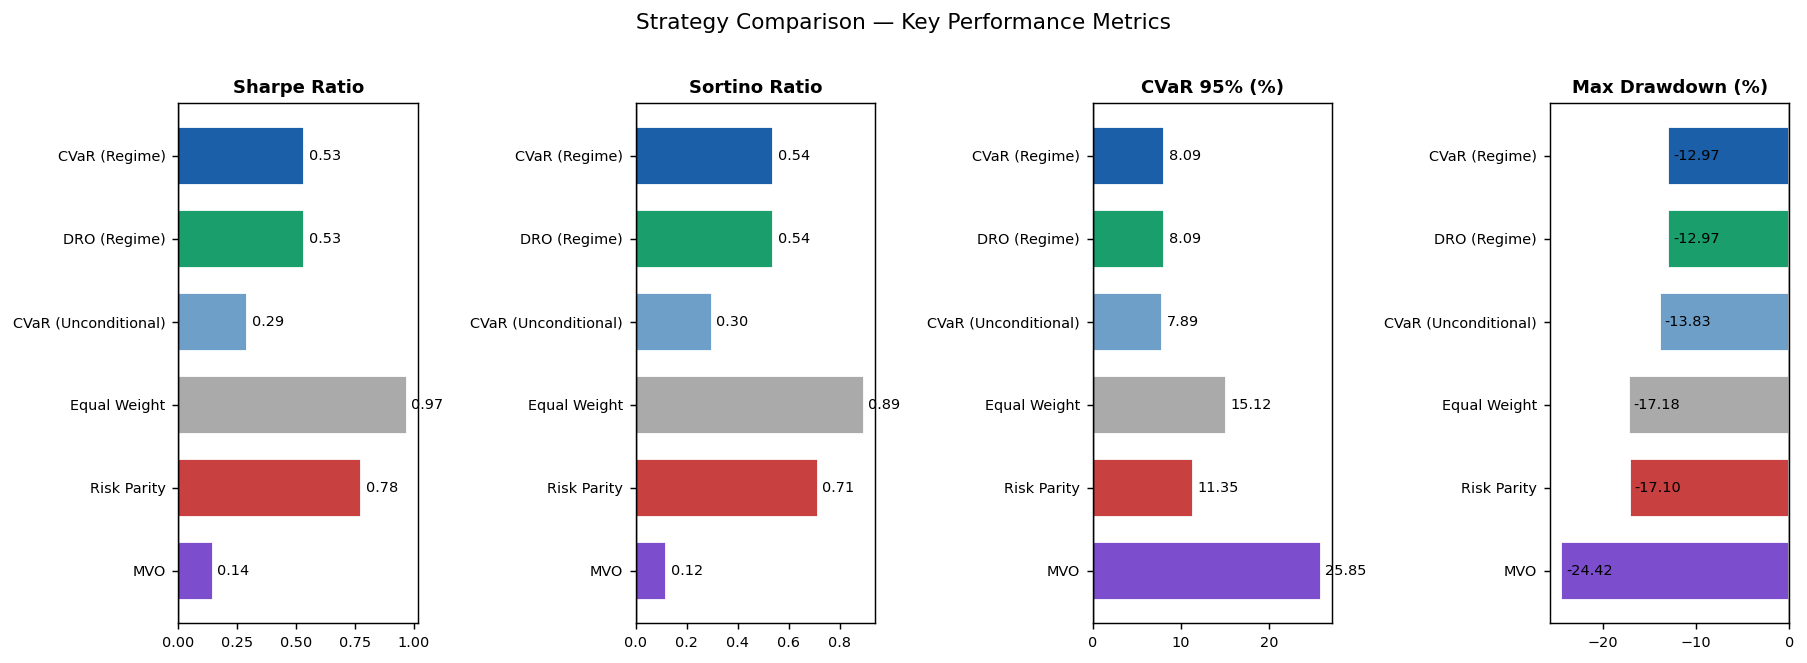

Saved: outputs/figures/09_metrics_comparison.png


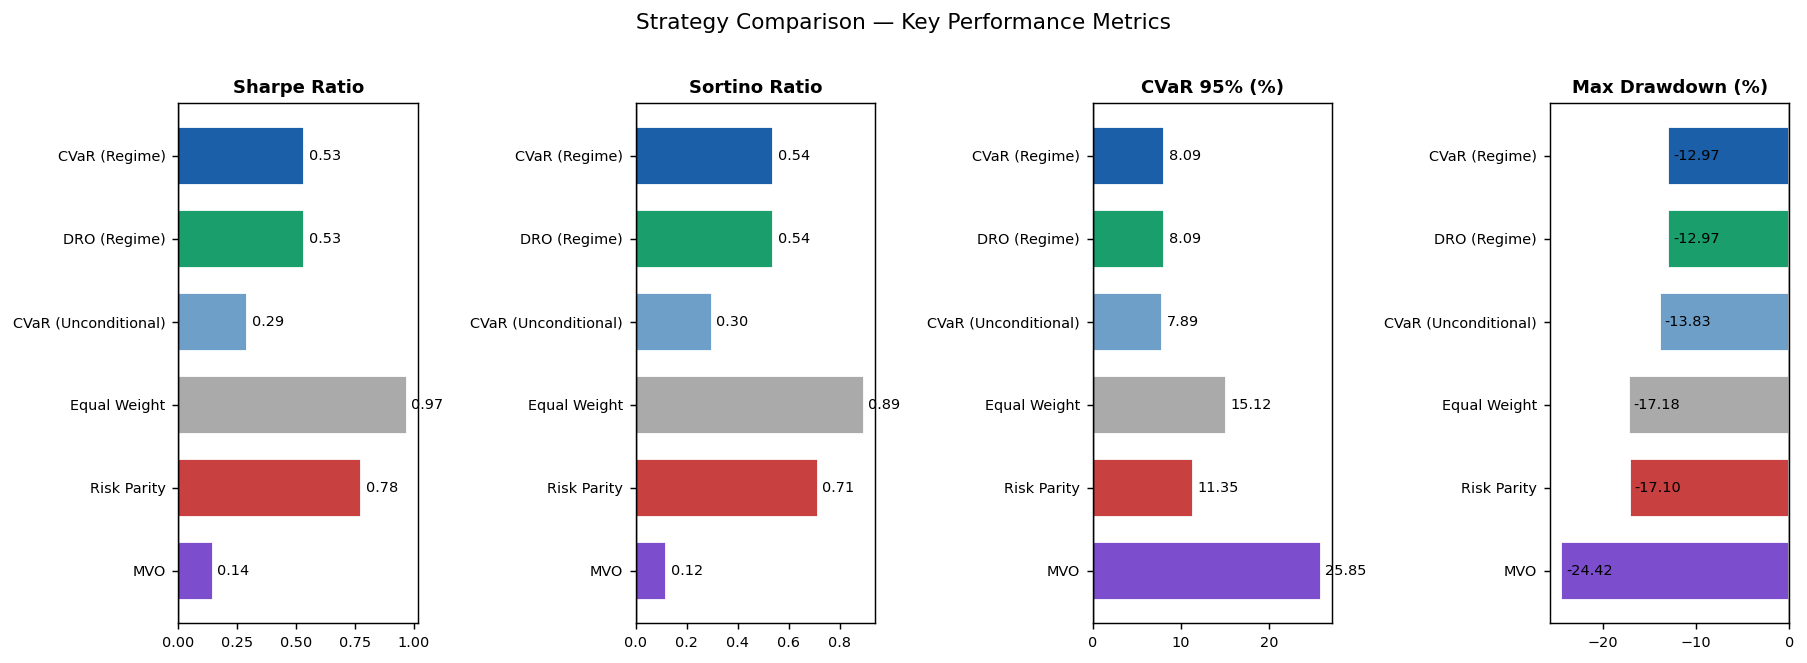

In [24]:
# ── Figure 2: Metrics Bar Chart ───────────────────────────────────────────────
# Four key metrics side-by-side
metrics_plot = ['Sharpe Ratio', 'Sortino Ratio', 'CVaR 95% (%)', 'Max Drawdown (%)']
# Find actual CVaR column name (alpha may vary)
cvar_col = [c for c in result.metrics.columns if c.startswith('CVaR')]
if cvar_col:
    metrics_plot[2] = cvar_col[0]

available_metrics = [m for m in metrics_plot if m in result.metrics.columns]
m_df = result.metrics[available_metrics].T

fig, axes = plt.subplots(1, len(available_metrics), figsize=(14, 5))
if len(available_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, available_metrics):
    vals   = m_df.loc[metric]
    colors = [COLOURS.get(s, '#999999') for s in vals.index]
    bars   = ax.barh(vals.index, vals.values, color=colors, edgecolor='white', height=0.7)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.axvline(0, color='black', lw=0.8)
    ax.invert_yaxis()
    ax.tick_params(labelsize=8)
    for bar, val in zip(bars, vals.values):
        xpos = bar.get_width() + (abs(vals.values).max() * 0.02)
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)

fig.suptitle('Strategy Comparison — Key Performance Metrics', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig('outputs/figures/09_metrics_comparison.png', dpi=150, bbox_inches='tight')
try:
    from IPython.display import display as _ipy_display
    _ipy_display(fig)
except Exception:
    plt.show()
print('Saved: outputs/figures/09_metrics_comparison.png')

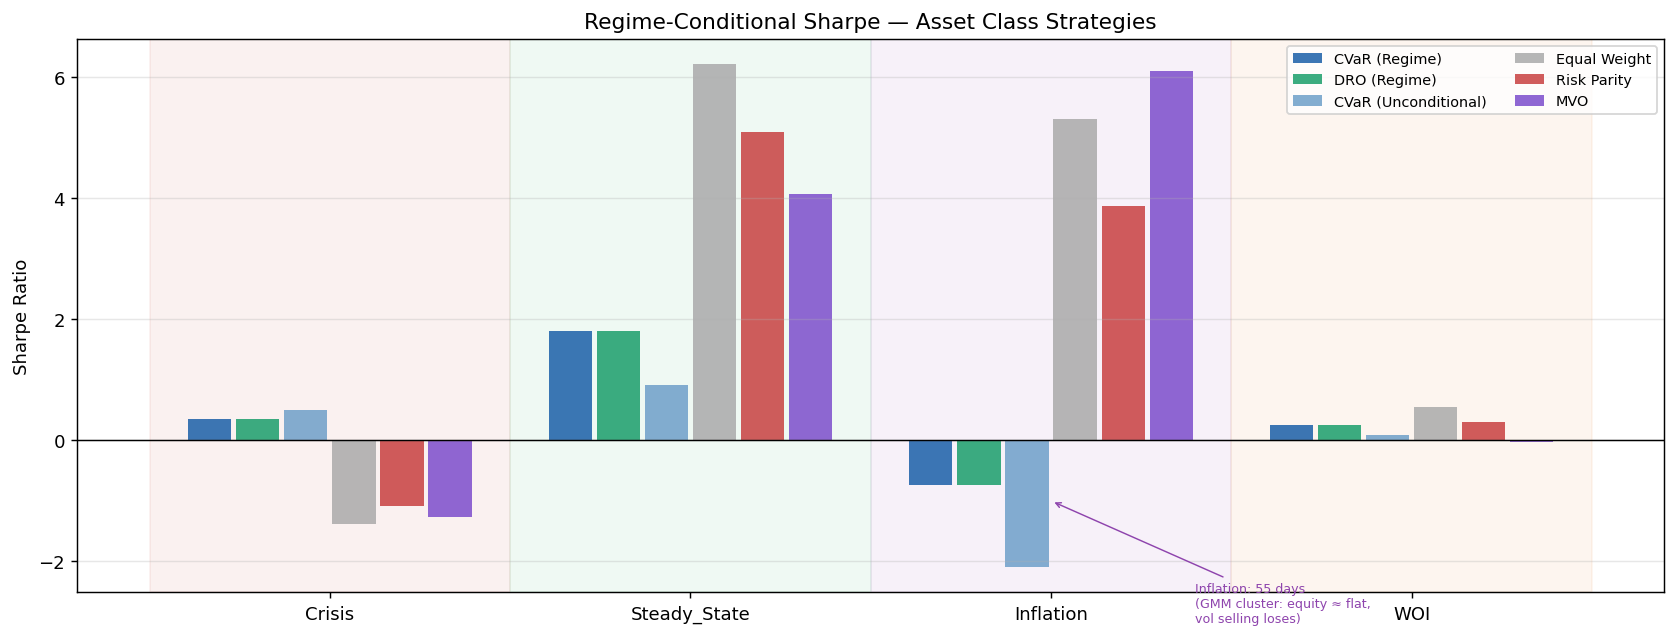

Saved: outputs/figures/10_regime_sharpe.png

Note: The GMM Inflation cluster (Equity factor mean = +0.16) represents
a vol/rotation regime — NOT the 2022 rate shock, which is labelled Crisis.
Inflation has only 55 test days — Sharpe estimate is highly noisy.
95% CI on Inflation Sharpe is very wide; treat with caution.


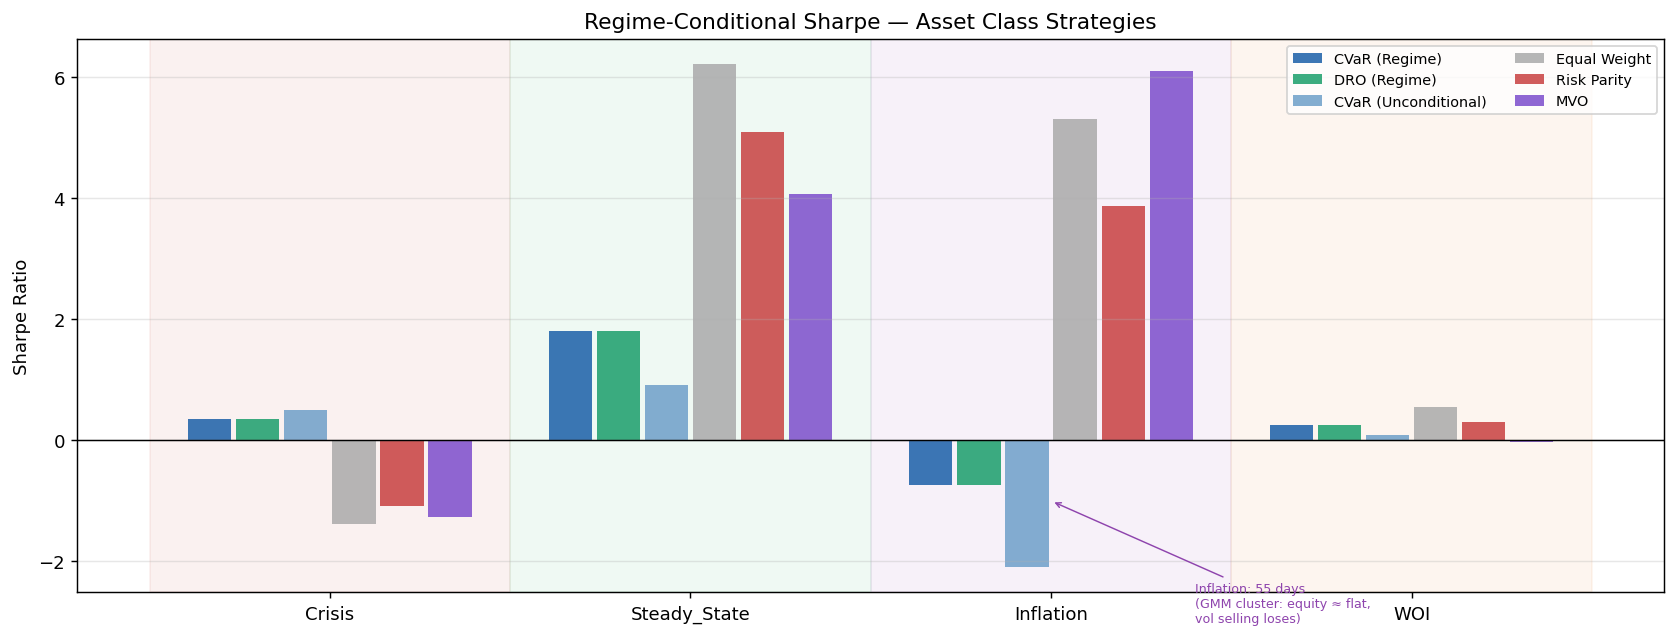

In [25]:
# ── Regime-conditional Sharpe ─────────────────────────────────────────────────
regime_sharpe_cols = [c for c in result.metrics.columns if c.startswith('Sharpe (')]

if regime_sharpe_cols:
    # Fixed display order: Crisis, Steady_State, Inflation, WOI
    _ORDER = ['Crisis', 'Steady_State', 'Inflation', 'WOI']
    ordered_cols = (
        [c for r in _ORDER for c in regime_sharpe_cols if r in c] +
        [c for c in regime_sharpe_cols if not any(r in c for r in _ORDER)]
    )
    rs_df = result.metrics[ordered_cols].T
    rs_df.index = [c.replace('Sharpe (','').rstrip(')') for c in rs_df.index]

    fig, ax = plt.subplots(figsize=(13, 5))
    n_s = len(rs_df.columns)
    x   = np.arange(len(rs_df.index))
    w   = 0.8 / n_s
    for i, strat in enumerate(rs_df.columns):
        vals = rs_df[strat].fillna(0).values
        ax.bar(x + (i - n_s/2 + 0.5)*w, vals, w*0.9,
               color=COLOURS.get(strat,'#999'), label=strat, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(rs_df.index, fontsize=10)
    ax.axhline(0, color='black', lw=0.8)
    for i, r in enumerate(rs_df.index):
        ax.axvspan(i-0.5, i+0.5, alpha=0.07,
                   color=REGIME_COLOURS.get(r,'#ddd'), zorder=0)

    ax.set_ylabel('Sharpe Ratio')
    ax.set_title('Regime-Conditional Sharpe — Asset Class Strategies', fontsize=12)
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(axis='y', alpha=0.3)

    # Annotation: explain Inflation regime characteristics
    n_inflation = (result.regime_labels == 'Inflation').sum()
    ax.annotate(
        f'Inflation: {n_inflation} days\n(GMM cluster: equity ≈ flat,\nvol selling loses)',
        xy=(rs_df.index.tolist().index('Inflation'), -1),
        xytext=(rs_df.index.tolist().index('Inflation') + 0.4, -3),
        fontsize=7, color='#8e44ad',
        arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=0.8),
    )

    plt.tight_layout()
    fig.savefig('outputs/figures/10_regime_sharpe.png', dpi=150, bbox_inches='tight')
    try:
        from IPython.display import display as _d; _d(fig)
    except Exception: plt.show()
    print('Saved: outputs/figures/10_regime_sharpe.png')
    print()
    print('Note: The GMM Inflation cluster (Equity factor mean = +0.16) represents')
    print('a vol/rotation regime — NOT the 2022 rate shock, which is labelled Crisis.')
    print(f'Inflation has only {n_inflation} test days — Sharpe estimate is highly noisy.')
    print('95% CI on Inflation Sharpe is very wide; treat with caution.')

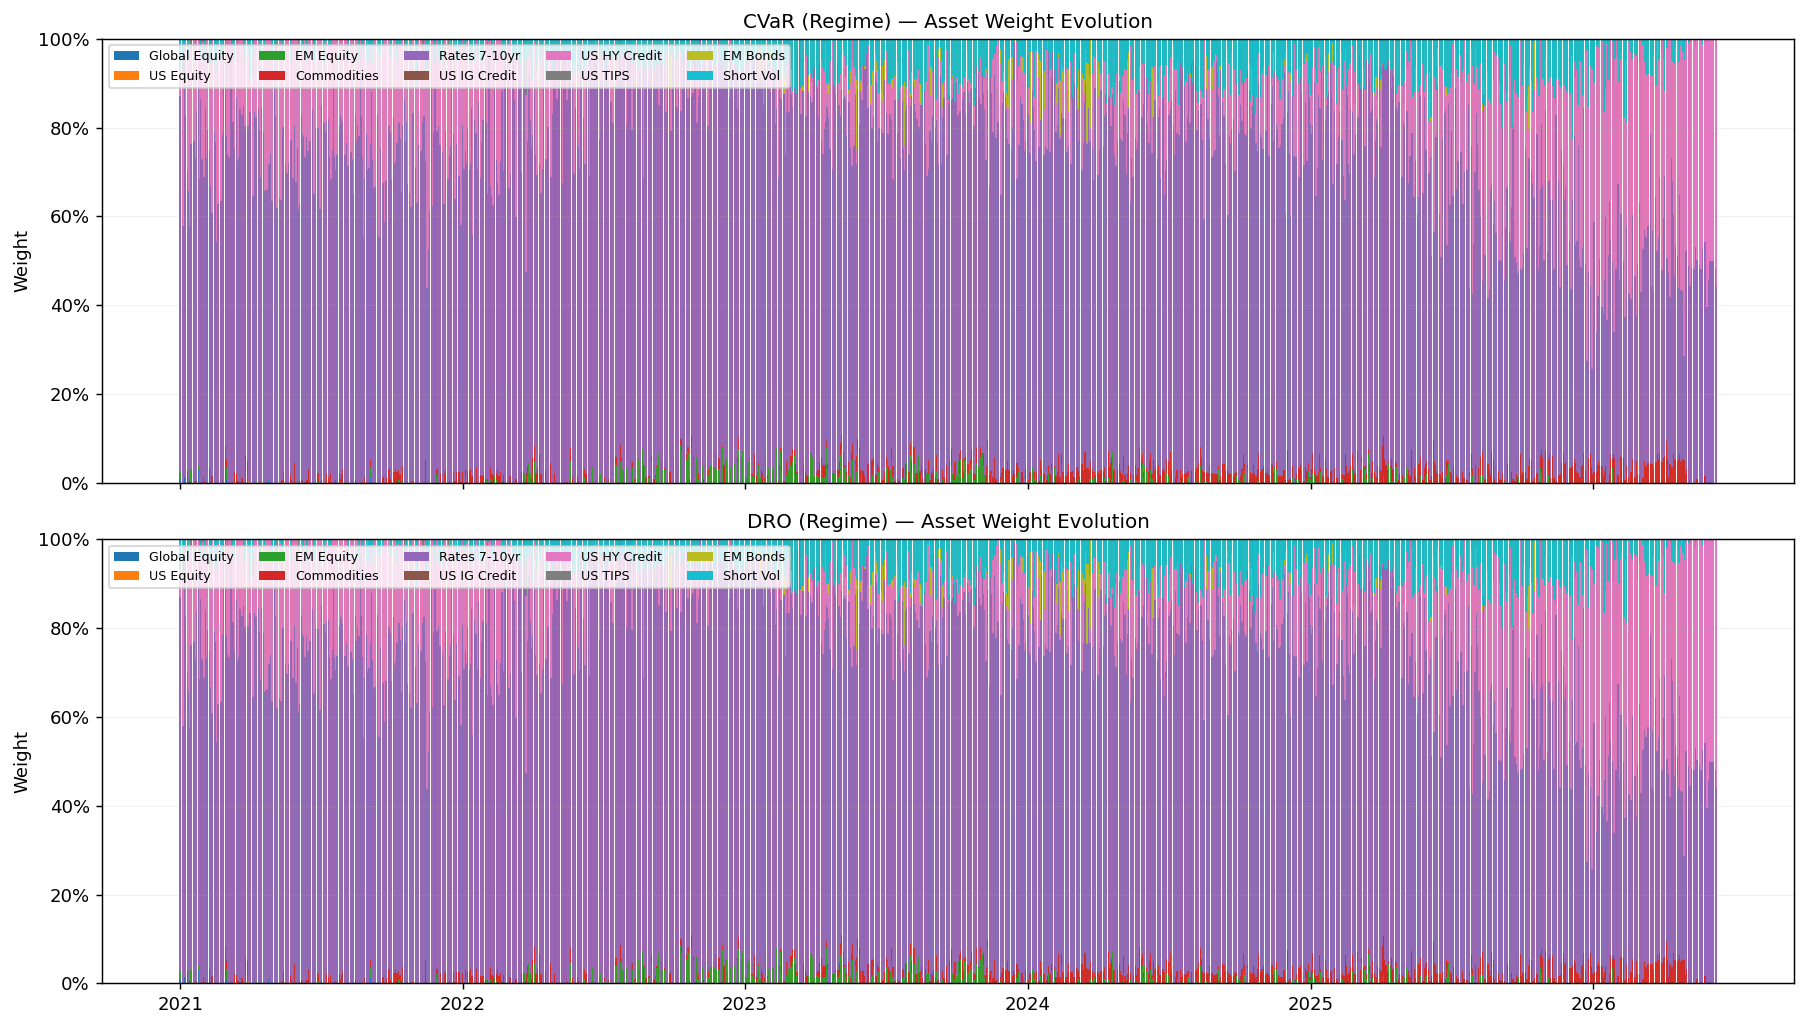

Saved: outputs/figures/11_weight_evolution.png


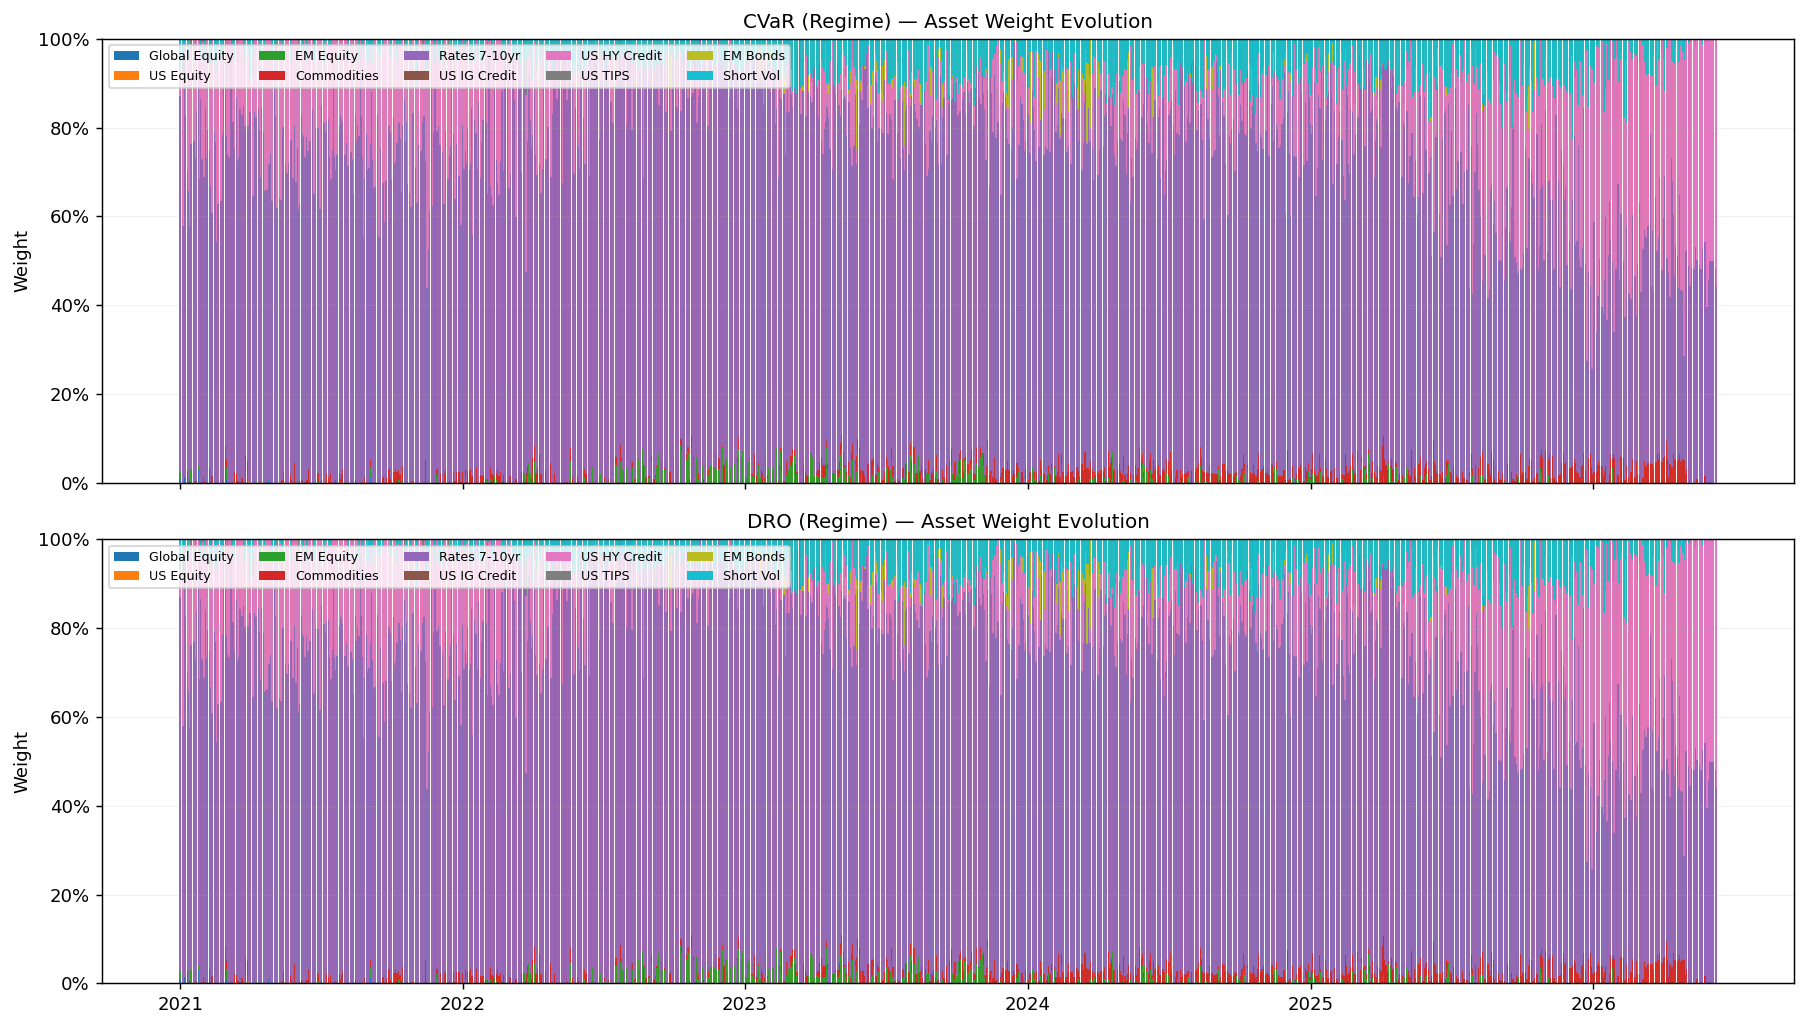

In [26]:
# ── Figure 4: CVaR & DRO Weight Evolution ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
colors = plt.cm.tab10.colors

for ax, strat in zip(axes, ['CVaR (Regime)', 'DRO (Regime)']):
    if strat not in result.weights_history:
        ax.text(0.5, 0.5, f'No data for {strat}', transform=ax.transAxes, ha='center')
        continue
    wh     = result.weights_history[strat]
    labels = [ASSET_LABELS.get(c, c) for c in wh.columns]
    bottom = np.zeros(len(wh))
    for j, (col, label) in enumerate(zip(wh.columns, labels)):
        vals = wh[col].values.clip(0)   # long-only: clip negatives to 0 (numerical noise)
        ax.bar(wh.index, vals, bottom=bottom,
               color=colors[j % 10], label=label, width=2, linewidth=0)
        bottom += vals
    ax.set_ylabel('Weight')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.set_title(f'{strat} — Asset Weight Evolution', fontsize=11)
    ax.legend(loc='upper left', fontsize=7, ncol=5)
    ax.grid(alpha=0.2, lw=0.5, axis='y')
    _regime_bg(ax, result.regime_labels, wh.index)

plt.tight_layout()
fig.savefig('outputs/figures/11_weight_evolution.png', dpi=150, bbox_inches='tight')
try:
    from IPython.display import display as _ipy_display
    _ipy_display(fig)
except Exception:
    plt.show()
print('Saved: outputs/figures/11_weight_evolution.png')

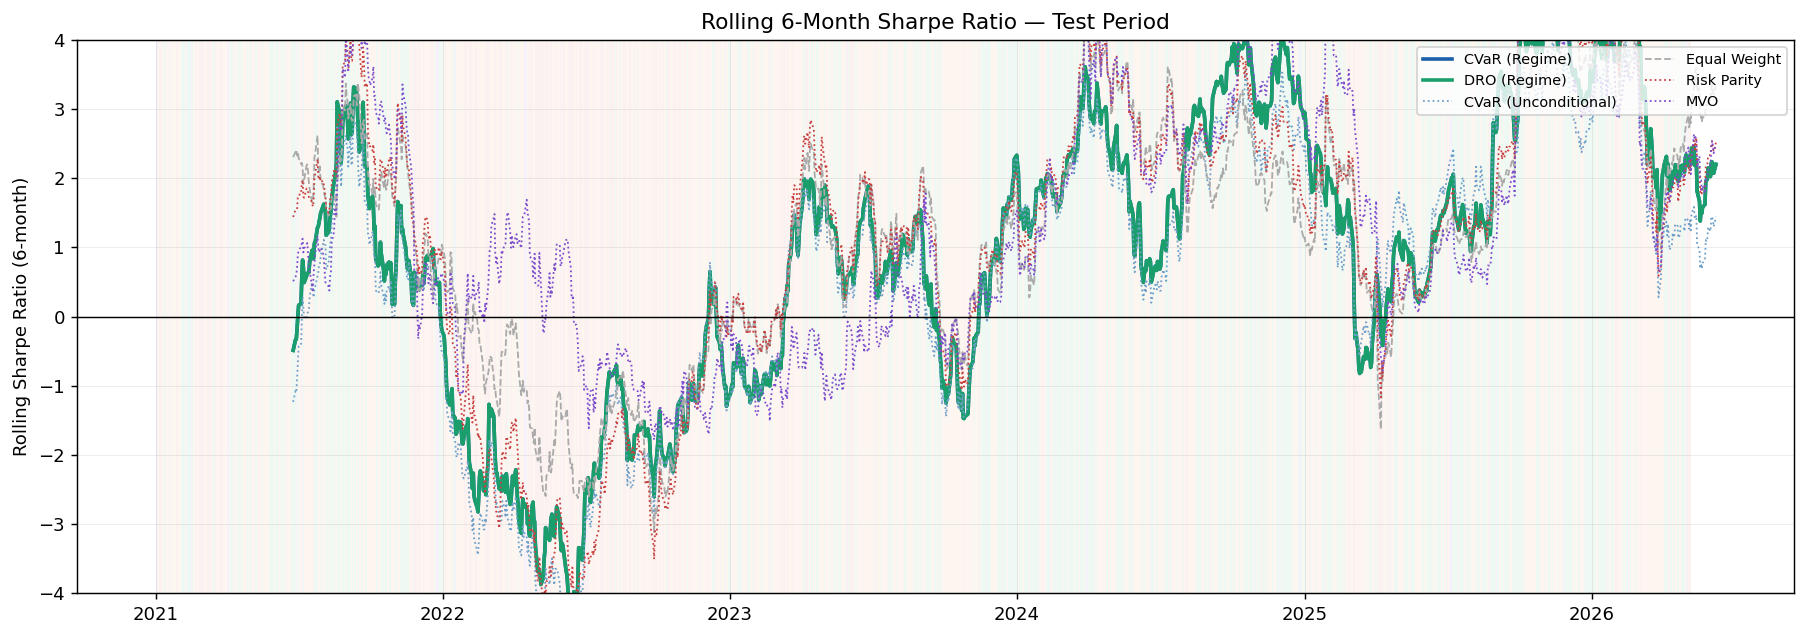

Saved: outputs/figures/12_rolling_sharpe.png


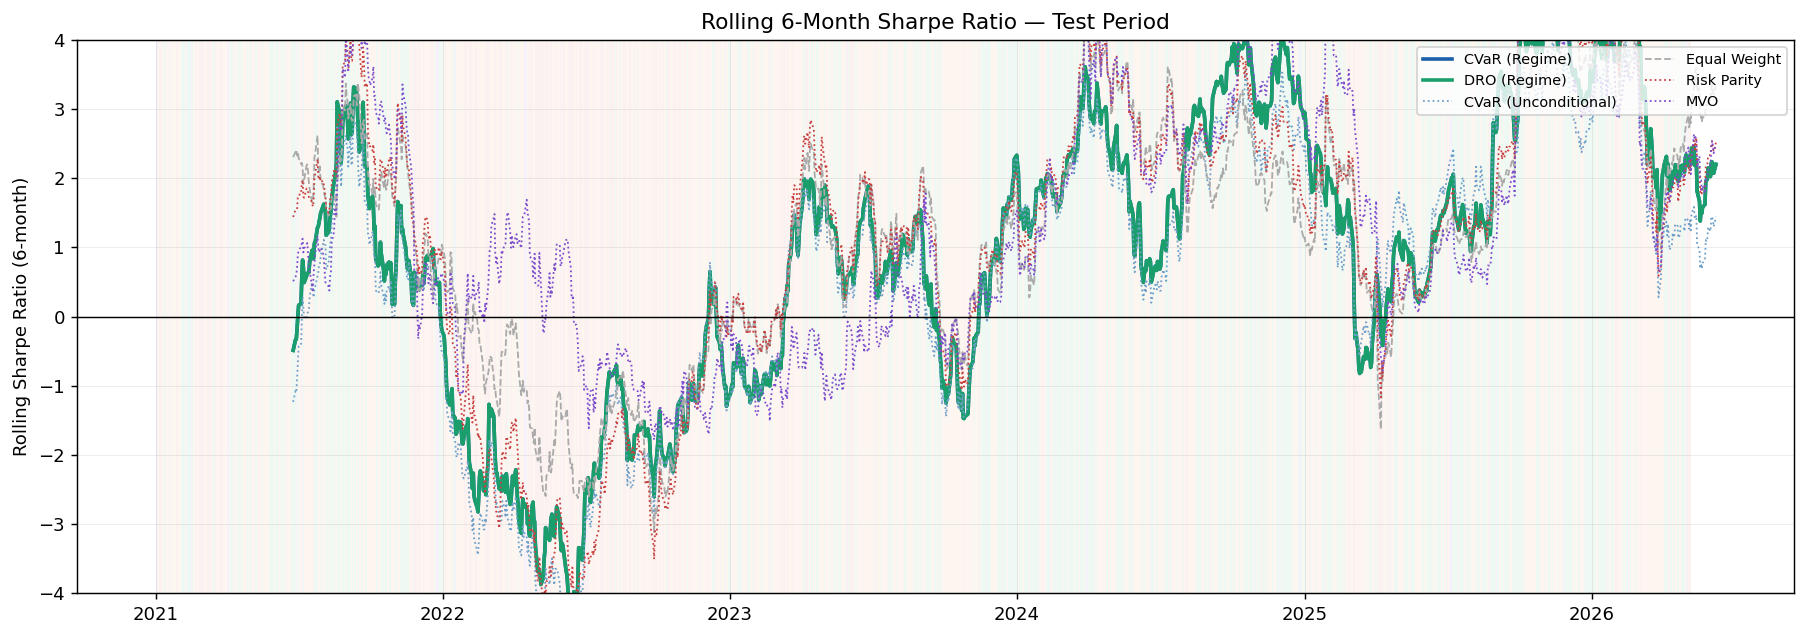

In [27]:
# ── Figure 5: Rolling Sharpe (252-day) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

roll_window = 126   # 6-month rolling
for strat, color in COLOURS.items():
    if strat not in pr.columns: continue
    roll_sharpe = (
        pr[strat].rolling(roll_window).mean() * 252 /
        (pr[strat].rolling(roll_window).std() * np.sqrt(252) + 1e-8)
    )
    lw = 2.0 if 'Regime' in strat else 1.0
    ls = '-'  if 'Regime' in strat else ('--' if strat in ['60/40','Equal Weight'] else ':')
    ax.plot(roll_sharpe.index, roll_sharpe, label=strat, color=color, lw=lw, ls=ls)

ax.axhline(0, color='black', lw=0.8)
_regime_bg(ax, result.regime_labels, pr.index)
ax.set_ylabel('Rolling Sharpe Ratio (6-month)')
ax.set_title('Rolling 6-Month Sharpe Ratio — Test Period', fontsize=12)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(alpha=0.25, lw=0.5)
ax.set_ylim(-4, 4)

plt.tight_layout()
fig.savefig('outputs/figures/12_rolling_sharpe.png', dpi=150, bbox_inches='tight')
try:
    from IPython.display import display as _ipy_display
    _ipy_display(fig)
except Exception:
    plt.show()
print('Saved: outputs/figures/12_rolling_sharpe.png')

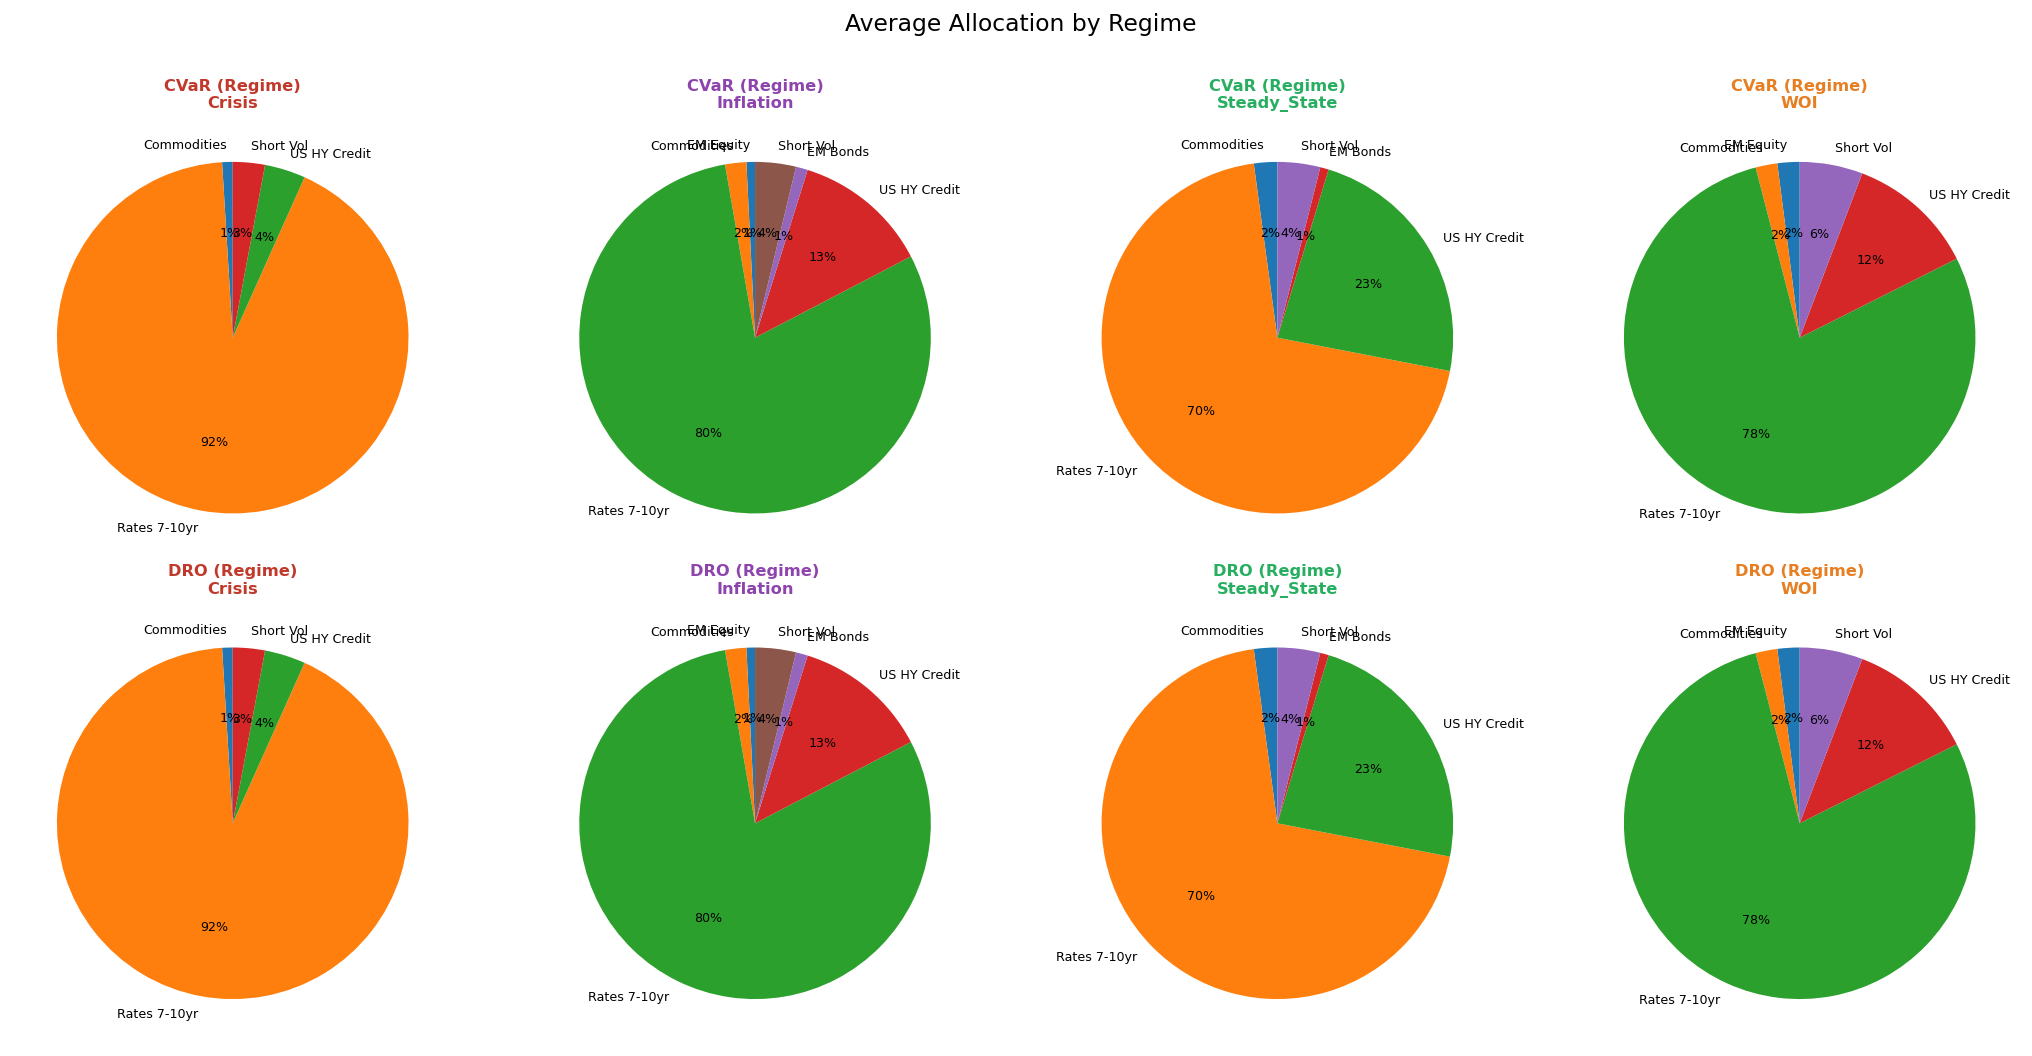

Saved: outputs/figures/13_regime_allocations.png


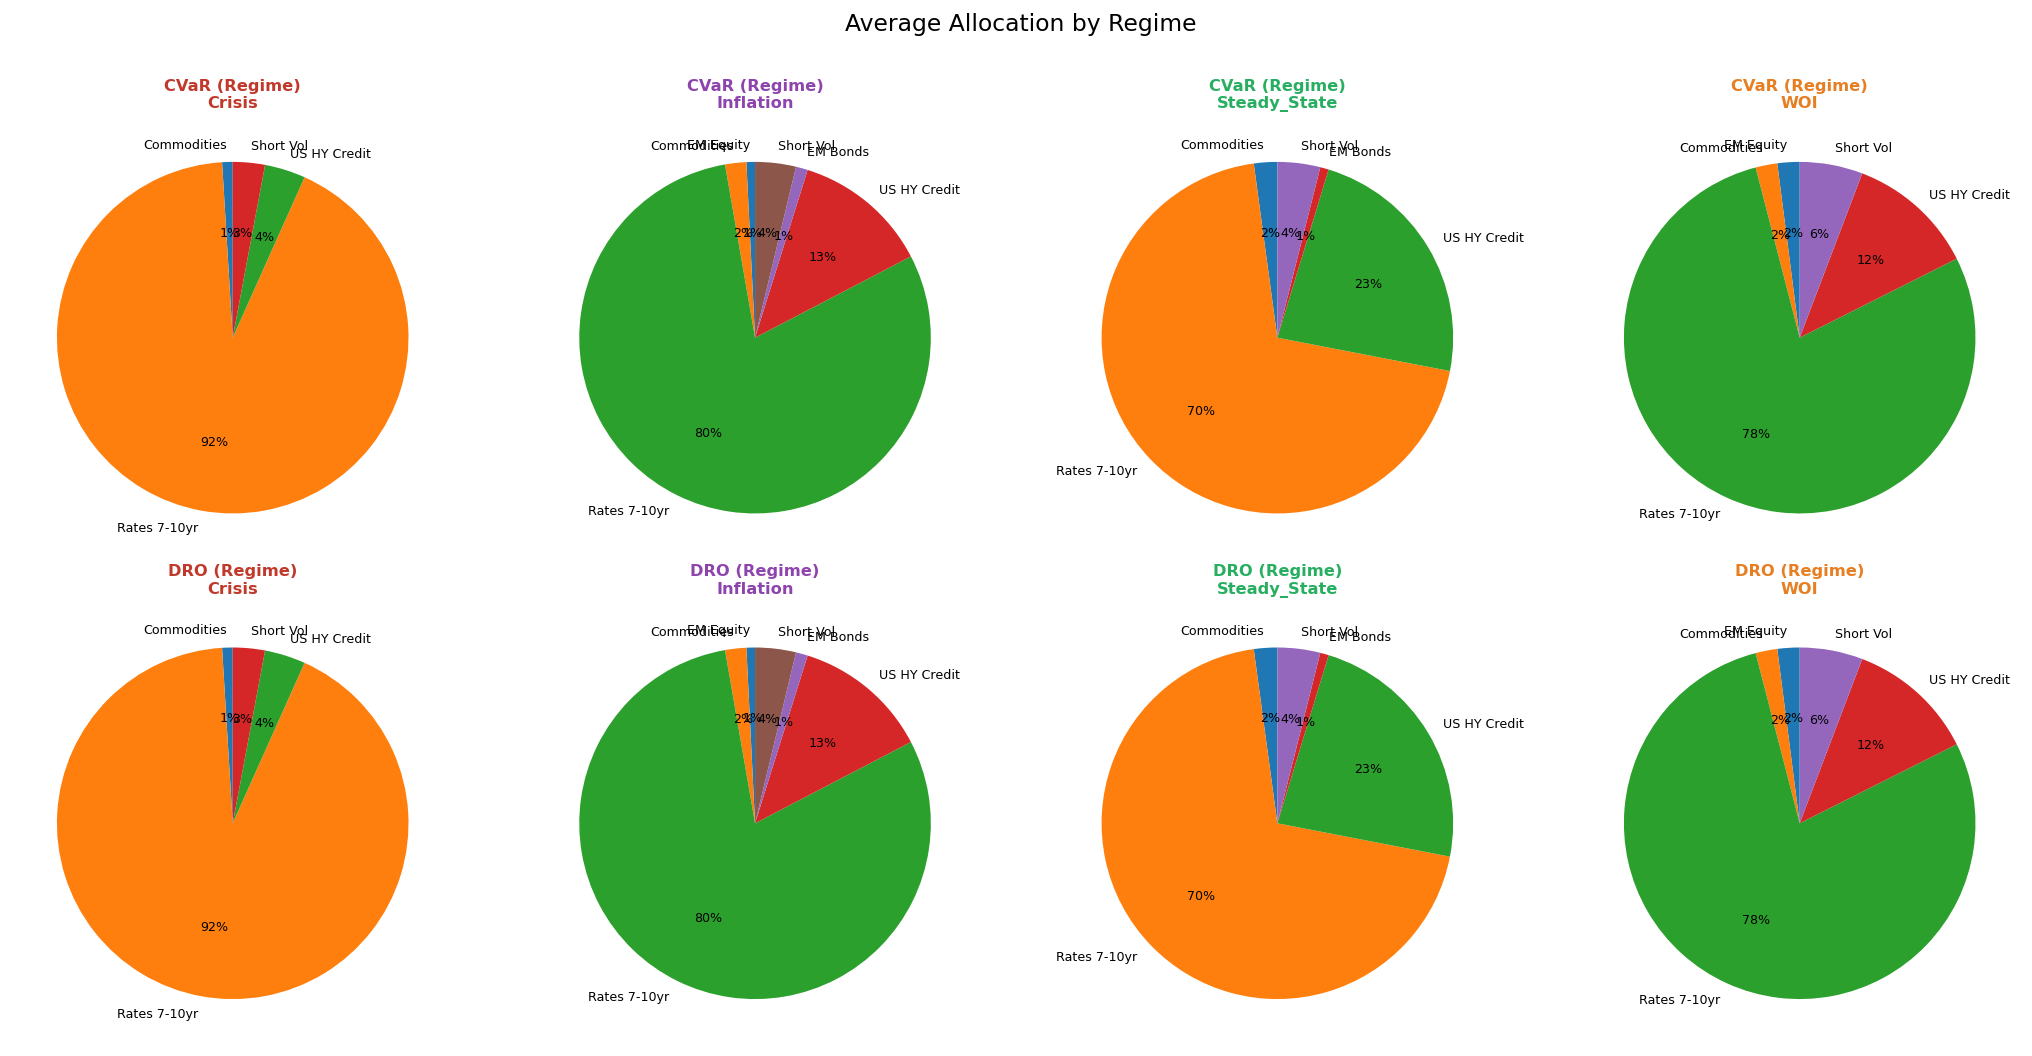

In [28]:
# ── Figure 6: Average Weights by Regime ──────────────────────────────────────
focus_strategies = ['CVaR (Regime)', 'DRO (Regime)']
regimes = sorted(result.regime_labels.dropna().unique())

fig, axes = plt.subplots(len(focus_strategies), len(regimes),
                          figsize=(4 * len(regimes), 4 * len(focus_strategies)),
                          squeeze=False)

for si, strat in enumerate(focus_strategies):
    if strat not in result.weights_history:
        continue
    wh = result.weights_history[strat]
    # Align weights to regime labels
    wh_aligned = wh.reindex(result.regime_labels.index, method='ffill').dropna()
    rl_aligned = result.regime_labels.reindex(wh_aligned.index).dropna()
    wh_aligned = wh_aligned.loc[rl_aligned.index]

    for ri, regime in enumerate(regimes):
        ax = axes[si][ri]
        mask = rl_aligned == regime
        if mask.sum() == 0:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            continue
        avg_w = wh_aligned[mask].mean()
        avg_w = avg_w[avg_w > 0.005]   # hide near-zero
        labels = [ASSET_LABELS.get(t, t) for t in avg_w.index]
        ax.pie(avg_w.values, labels=labels, autopct='%1.0f%%',
               textprops={'fontsize': 7}, startangle=90,
               colors=plt.cm.tab10.colors[:len(avg_w)])
        rc = REGIME_COLOURS.get(regime, '#888')
        ax.set_title(f'{strat}\n{regime}', fontsize=9,
                     color=rc, fontweight='bold')

fig.suptitle('Average Allocation by Regime', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig('outputs/figures/13_regime_allocations.png', dpi=150, bbox_inches='tight')
try:
    from IPython.display import display as _ipy_display
    _ipy_display(fig)
except Exception:
    plt.show()
print('Saved: outputs/figures/13_regime_allocations.png')

In [29]:
# ── Save weights history ──────────────────────────────────────────────────────
for strat, wh in result.weights_history.items():
    safe_name = strat.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
    wh.to_csv(f'outputs/weights_{safe_name}.csv')
    print(f'Saved: outputs/weights_{safe_name}.csv')

Saved: outputs/weights_CVaR_Regime.csv
Saved: outputs/weights_DRO_Regime.csv
Saved: outputs/weights_CVaR_Unconditional.csv
Saved: outputs/weights_Equal_Weight.csv
Saved: outputs/weights_Risk_Parity.csv
Saved: outputs/weights_MVO.csv


In [30]:
# ── Summary printout ──────────────────────────────────────────────────────────
print('=' * 80)
print('SUMMARY — Regime-Conditional CVaR / DRO vs Benchmarks')
print('=' * 80)

primary_cols = ['Ann. Return (%)', 'Ann. Vol (%)', 'Sharpe Ratio', 'Sortino Ratio']
cvar_col     = [c for c in result.metrics.columns if c.startswith('CVaR')]
tail_cols    = cvar_col + ['Max Drawdown (%)', 'Calmar Ratio']

print('\n--- Return & Risk ---')
print(result.metrics[[c for c in primary_cols if c in result.metrics.columns]].to_string())

print('\n--- Tail Risk & Drawdown ---')
print(result.metrics[[c for c in tail_cols if c in result.metrics.columns]].to_string())

regime_cols = [c for c in result.metrics.columns if c.startswith('Sharpe (')]
if regime_cols:
    print('\n--- Regime-Conditional Sharpe ---')
    print(result.metrics[regime_cols].to_string())

SUMMARY — Regime-Conditional CVaR / DRO vs Benchmarks

--- Return & Risk ---
                      Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Sortino Ratio
CVaR (Regime)                  1.9600        3.6700        0.5340         0.5400
DRO (Regime)                   1.9600        3.6700        0.5340         0.5400
CVaR (Unconditional)           1.0700        3.6700        0.2920         0.2990
Equal Weight                   6.1400        6.3300        0.9690         0.8930
Risk Parity                    3.6500        4.7100        0.7760         0.7130
MVO                            1.2900        8.9300        0.1450         0.1190

--- Tail Risk & Drawdown ---
                      CVaR 95% (%)  Max Drawdown (%)  Calmar Ratio
CVaR (Regime)               8.0900          -12.9700        0.1510
DRO (Regime)                8.0900          -12.9700        0.1510
CVaR (Unconditional)        7.8900          -13.8300        0.0770
Equal Weight               15.1200          -17.1800      